In [1]:
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
import numpy as np
import pickle as pkl
import pandas as pd

# Demostración: K-Means clustering

> **Cómo usar este cuaderno:** las slides de la clase (`slides/8_Clustering.pdf`) son el *mapa conceptual* — distancias, por qué escalar es obligatorio, cuándo falla cada algoritmo y si los grupos son reales. **Todo el código vive en los notebooks**: esta clase se acompaña de **dos**, `Clustering_K-means_Hierarchical.ipynb` (este) y `Clustering_DBSCAN.ipynb`, en ese orden. Aquí está la referencia completa y aquí hacemos los ejercicios en clase.

Nota: Ejemplo adaptado de "Hands on Machine Learning" de Geron Aurelien.

In [5]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

Creemos un data set sintético para demostrar el algoritmo de K-Means usando la función make_blobs de Scikit-Learn.

(2000, 2)


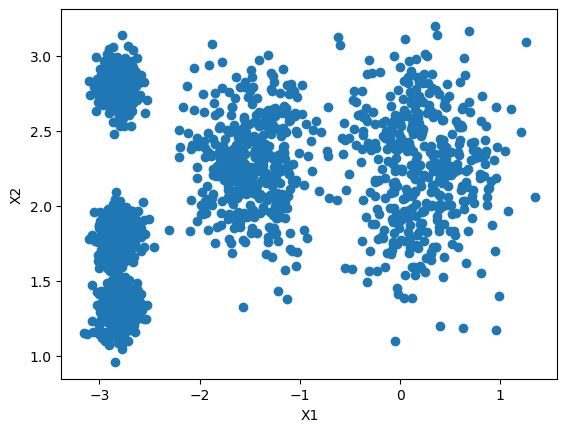

In [71]:
# Los centros de nuestors grupos, k=5
blob_centers = np.array([
    [ 0.2,  2.3],
    [-1.5 ,  2.3],
    [-2.8,  1.8],
    [-2.8,  2.8],
    [-2.8,  1.3]
])

# El "tamaño" de cada grupo (desviación estándar)
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

X, y = make_blobs(
    n_samples=2000,
    centers=blob_centers,
    cluster_std=blob_std,
    random_state=7
)

print(X.shape)
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('X1')
plt.ylabel('X2');

Ahora, creamos una instancia de la clase, sabemos que queremos 5 grupos, aunque no siempre estaremos seguros.

In [83]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=1, n_init='auto')
kmeans.fit(X)

y_pred = kmeans.predict(X)
# Esta información también se encuentra en KMeans().labels_
# ¿Para qué más podemos usar predict entonces?
y_pred

array([1, 4, 0, ..., 3, 0, 4], dtype=int32)

Los centroides estan almacenados en:

In [84]:
centroids = kmeans.cluster_centers_
centroids

array([[ 0.20876306,  2.25551336],
       [-2.80037642,  1.30082566],
       [-1.46679593,  2.28585348],
       [-2.79290307,  2.79641063],
       [-2.80389616,  1.80117999]])

Miremos la asignación de grupos.

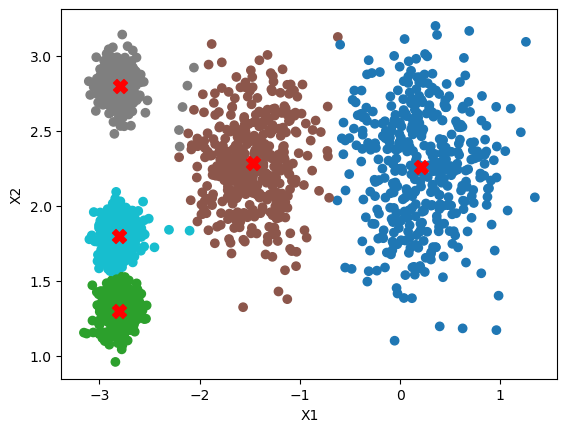

In [85]:
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='tab10')
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='X', s=100)
plt.xlabel('X1')
plt.ylabel('X2');

Podemos predecir el grupo de nuevas observaciones. Ojo, no se recalculan los centroides.

In [31]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([4, 4, 3, 3], dtype=int32)

La distancia a los centroides se puede obtener con el método `transform`. Esto es similar a un "soft clustering".

In [33]:
kmeans.transform(X_new).round(2)

array([[2.84, 0.59, 1.5 , 2.9 , 0.31],
       [5.82, 2.97, 4.48, 5.85, 2.69],
       [1.46, 3.11, 1.69, 0.29, 3.47],
       [0.97, 3.09, 1.55, 0.36, 3.36]])

Recordemos que durante la presentación discutimos acerda de la incialización del algoritmo y como una mala incialización puede llevar a un resultado sub-optimo. En Scikit-Learn podemos controlar este comportamiento con los parámetros `n_init` y `init`.
Con inicialización aleatoria es necesario repetir varia veces el algoritmo para encontrar una buena partición.

K-mean++ es una forma de inicializar el algoritmo K-means de una manera más inteligente, para mantener los puntos de inicialización alejados entre sí.
Para realizar la inicialización, primero elige un centroide inicial al azar entre las observaciones en 𝑋. Luego, para los centroides restantes, elige el siguiente centroide entre los puntos restantes en 𝑋 con probabilidad proporcional a la distancia al cuadrado desde el centroide más cercano.

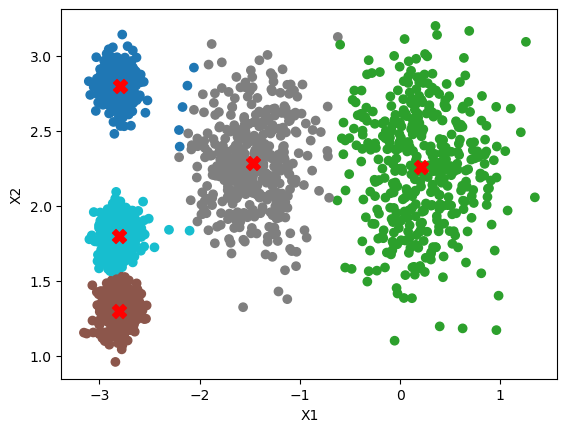

In [90]:
# Probemos diferentes combinaciones de n_init e init
# kmeans = KMeans(n_clusters=k, init='random', n_init=1)
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=100)
y_pred = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='tab10')
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='X', s=100)
plt.xlabel('X1')
plt.ylabel('X2');

También es posibles especificar la posición inicial de los centroides.

Para seleccionar el mejor modelo, necesitaremos una forma de evaluar su rendimiento. Desafortunadamente, la agrupación es una tarea no supervisada, por lo que no tenemos las etiquetas. Pero podemos medir la distancia entre cada instancia y su centroide. A la suma de las distancias cuadradas a su centroide asignado se le llama inercia. De hecho, cuando ejecutamos KMeans con diferentes inicializaciones, el agoritmo elige la de menor inercia.

La inercia siempre disminuye con el número de grupos (k), pero podemos evaluar su tasa de cambio para encontrar el punto de inflexión. A este método se le conoce como el método del codo.

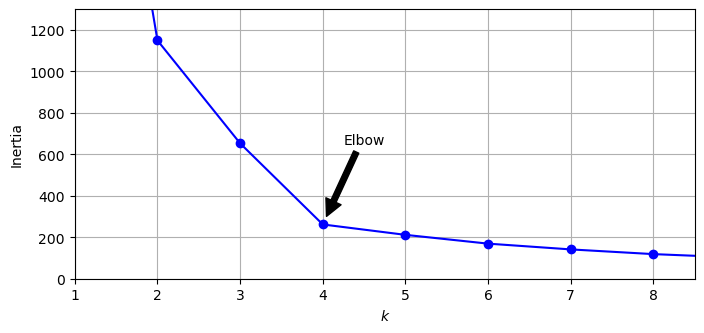

In [101]:
kmeans_per_k = [KMeans(n_clusters=k, n_init=10, init='k-means++').fit(X)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.annotate("", xy=(4, inertias[3]), xytext=(4.45, 650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(4.5, 650, "Elbow", horizontalalignment="center")
plt.axis([1, 8.5, 0, 1300])
plt.grid();

Parece que 4 grupos es una buena opción, aunque combina los grupos más pequeños.

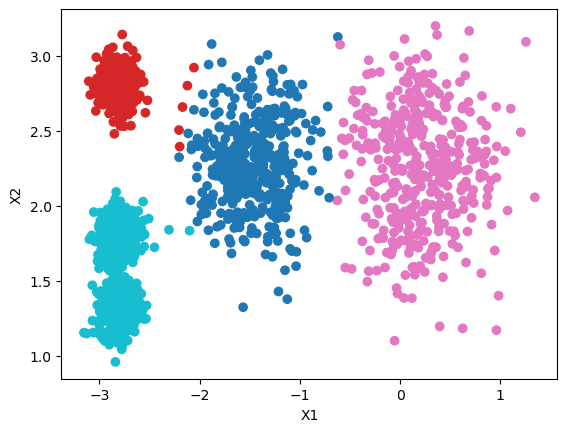

In [98]:
plt.scatter(X[:, 0], X[:, 1], c=kmeans_per_k[3].labels_, cmap='tab10')
plt.xlabel('X1')
plt.ylabel('X2');

Otro enfoque es observar la puntuación de silueta, que es el coeficiente de silueta medio sobre todas las obervaciones. El coeficiente de silueta de una instancia es igual a $(b - a) / \max(a, b)$ donde $a$ es la distancia media a las otras instancias del mismo grupo y $b$ es la distancia media a las instancias del siguiente clúster más cercano (definido como el que minimiza $b$, excluyendo el propio clúster de la instancia). El coeficiente de silueta puede variar entre -1 y +1: un coeficiente cercano a +1 significa que la instancia está dentro de su propio grupo y lejos de otros grupos, mientras que un coeficiente cercano a 0 significa que está cerca del límite de un grupo. y finalmente un coeficiente cercano a -1 significa que es posible que la instancia haya sido asignada al clúster incorrecto.

In [99]:
from sklearn.metrics import silhouette_score

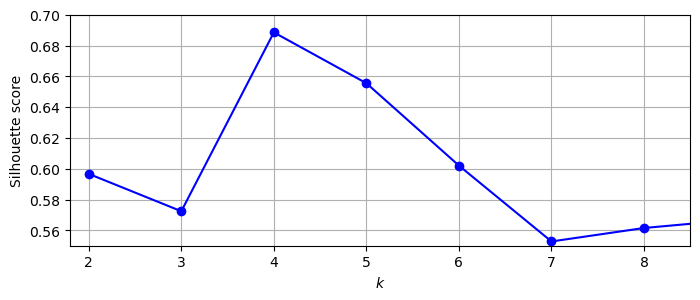

In [100]:
silhouette_scores = [
    silhouette_score(X, model.labels_)
    for model in kmeans_per_k[1:]
]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid();

Como puede ver, esta visualización es mucho más rica que la anterior: en particular, aunque confirma que $k=4$ es una muy buena elección, también subraya el hecho de que $k=5$ también es bastante buena.

Se obtiene una visualización aún más informativa cuando se traza el coeficiente de silueta de cada instancia, ordenado por el grupo al que están asignados y por el valor del coeficiente. Esto se llama diagrama de silueta:

In [107]:
from yellowbrick.cluster import silhouette_visualizer

In [113]:
kmeans_per_k[2:6]

[KMeans(n_clusters=3, n_init=10),
 KMeans(n_clusters=4, n_init=10),
 KMeans(n_clusters=5, n_init=10),
 KMeans(n_clusters=6, n_init=10)]

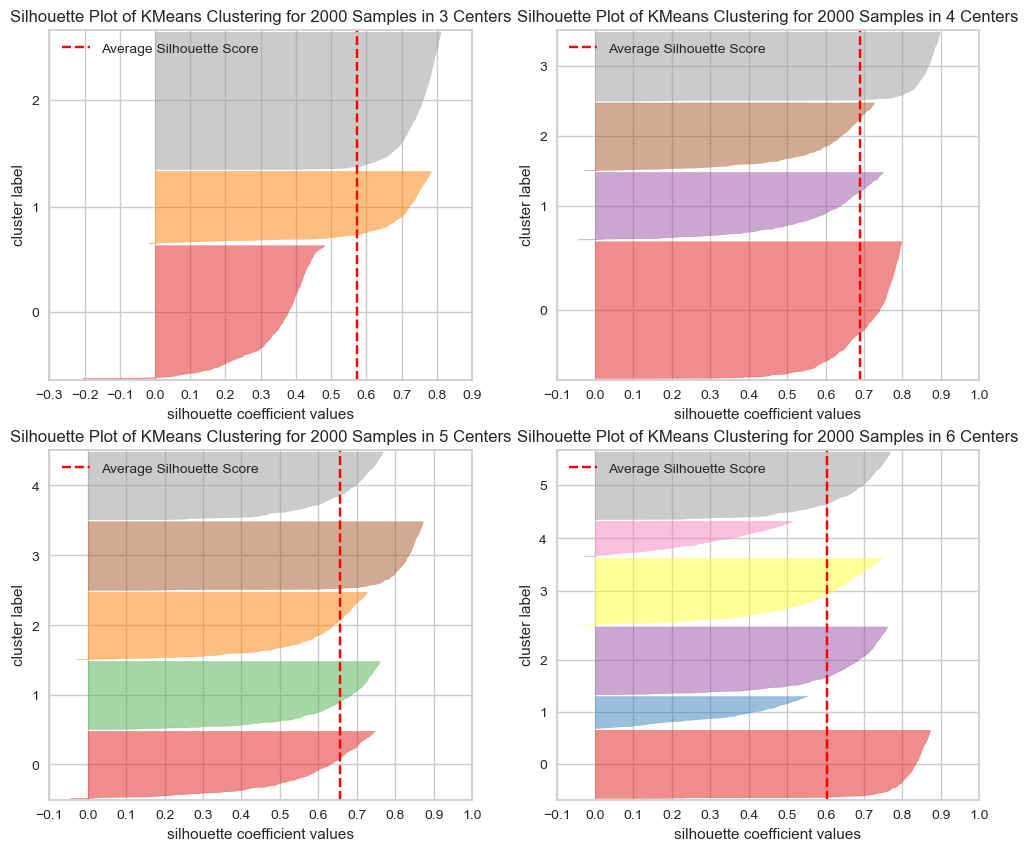

In [117]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

visualizers = [silhouette_visualizer(model, X, ax=ax, show=False) for model, ax in zip(kmeans_per_k[2:6], axes)]

Como puede ver, $k=5$ parece la mejor opción aquí, ya que todos los grupos son aproximadamente del mismo tamaño y todos cruzan la línea discontinua, que representa la puntuación media de la silueta.

Sin embargo, K-Means asume grupos esféricos, e intenta encontrar este tipo de grupos. Veamos que pasa si esta suposición no es correcta.

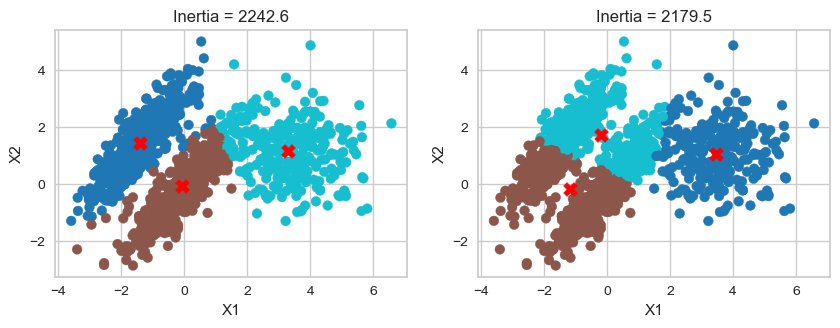

In [126]:
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]

kmeans_good = KMeans(n_clusters=3,
                     init=np.array([[-1.5, 2.5], [0.5, 0], [4, 0]]),
                     n_init=1, random_state=42)
kmeans_bad = KMeans(n_clusters=3, random_state=42, n_init=100, init='k-means++')

kmeans_good.fit(X)
kmeans_bad.fit(X)

plt.figure(figsize=(10, 3.2))

plt.subplot(121)
plt.scatter(X[:, 0], X[:, 1], c=kmeans_good.labels_, cmap='tab10')
plt.scatter(kmeans_good.cluster_centers_[:, 0], kmeans_good.cluster_centers_[:, 1], color='red', marker='X', s=100)
plt.xlabel('X1')
plt.ylabel('X2');
plt.title(f"Inertia = {kmeans_good.inertia_:.1f}")

plt.subplot(122)
plt.scatter(X[:, 0], X[:, 1], c=kmeans_bad.labels_, cmap='tab10')
plt.scatter(kmeans_bad.cluster_centers_[:, 0], kmeans_bad.cluster_centers_[:, 1], color='red', marker='X', s=100)
plt.xlabel('X1')
plt.ylabel('X2');
plt.title(f"Inertia = {kmeans_bad.inertia_:.1f}");

# Ejemplo aplicado: Human Tumor Microarray Data

Ejemplo tomado del libro "Elements of Statistical Learning". La implementación es propia.

Aplicamos agrupación jerárquica a datos de microarrays de tumores humanos. Los datos son una matriz de 6830 × 64 de números reales, cada uno de los cuales representa una medida de expresión para un gen (fila) y una muestra (columna). Agrupamos las muestras (64 columnas), cada una representada como un vector dimensional 6830 de expresiones génicas. Cada muestra está etiquetada según el tipo de tumor. Queremos explorar si el proceso de agrupamiento agrupa tipos de tumores similares en el mismo grupo.

--2021-08-23 23:56:29--  https://github.com/gperaza/UL-lecture-notes/blob/gh-pages/Data/nci.micro.data.pkl?raw=true
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/gperaza/UL-lecture-notes/raw/gh-pages/Data/nci.micro.data.pkl [following]
--2021-08-23 23:56:29--  https://github.com/gperaza/UL-lecture-notes/raw/gh-pages/Data/nci.micro.data.pkl
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/gperaza/UL-lecture-notes/gh-pages/Data/nci.micro.data.pkl [following]
--2021-08-23 23:56:29--  https://raw.githubusercontent.com/gperaza/UL-lecture-notes/gh-pages/Data/nci.micro.data.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubuser

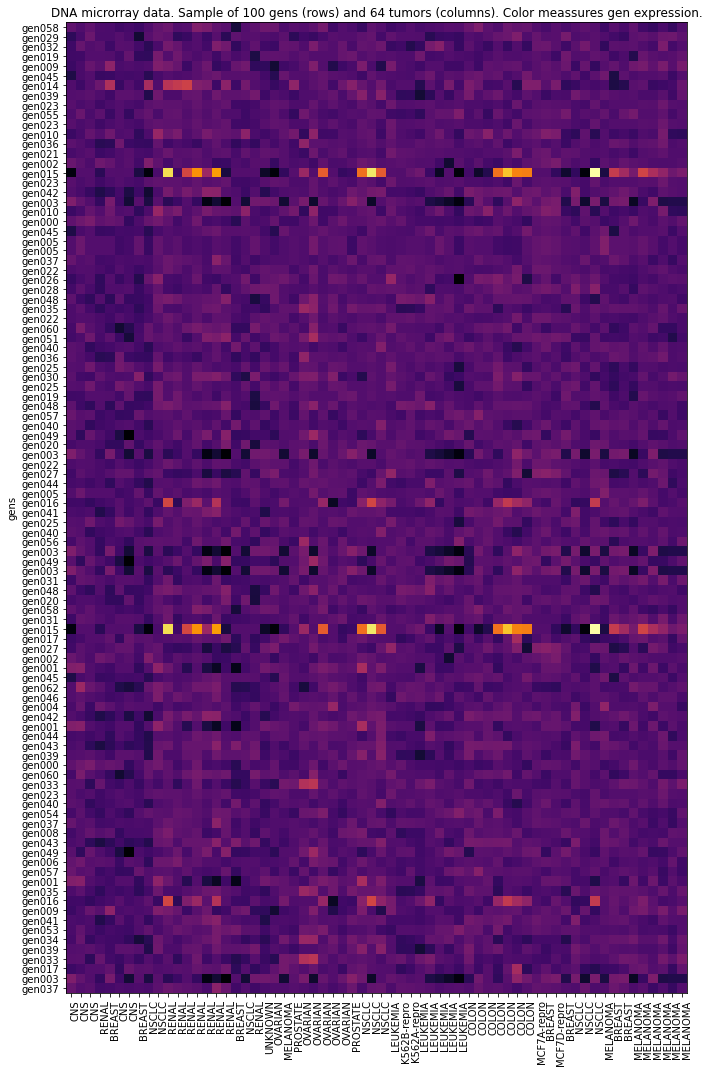

In [3]:
# Import micro-array data (el archivo viene en el repo, en data/)
with open('../data/nci.micro.data.pkl', 'rb') as f:
    data_dic = pkl.load(f)
    X = data_dic['data'].T  # tranpose to get samples in rows
    labels = data_dic['labels']

fig, ax = plt.subplots(figsize=(15,15))
# Show a sample of genes
gens_idx = np.random.randint(len(X), size=100)
im = ax.imshow(X.T[gens_idx,:], cmap='inferno')

gens = [f'gen{x:03}' for x in gens_idx]

# We want to show all ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(gens)))
ax.set_xticklabels(labels)
ax.set_yticklabels(gens)
ax.set_ylabel('gens')

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=90, ha="right",
         rotation_mode="anchor")

ax.set_title("DNA microrray data. Sample of 100 gens (rows) and 64 tumors (columns). Color meassures gen expression.")
fig.tight_layout()

Para comparar HC con un modelo base, primero usamos la agrupación de K-medias en los datos. Para determinar el número de conglomerados, tratamos de buscar una torcedura, o codo, en la curva de suma de cuadrados. Como no hay un codo claro, seguimos la referencia original y elegimos arbitrariamente K = 3.

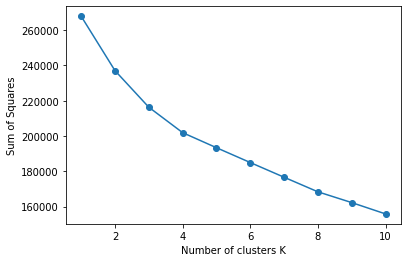

In [4]:
from sklearn.cluster import KMeans

# How many clusters?
sum_sq = []
for K in range(1,11):
    kmeans = KMeans(n_clusters=K, random_state=0).fit(X)
    sum_sq.append(kmeans.inertia_)
plt.plot(range(1,11), sum_sq, '-o')
plt.xlabel('Number of clusters K')
plt.ylabel('Sum of Squares');

In [7]:
# No clear elbow, choose K=3.
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
C = kmeans.labels_

# Build table with label count
labels = np.array(labels)
unique_labels = np.unique(labels)
l_counts = []
for k in range(3):
    k_counts = []
    # Look at members of cluaster k
    y_k = labels[C==k]
    # Count # isntances of each label in cluster k
    for label in unique_labels:
        k_counts.append((y_k == label).sum())
    l_counts.append(k_counts)

df = pd.DataFrame(data=l_counts, columns=unique_labels)
df

,BREAST,CNS,COLON,K562A-repro,K562B-repro,LEUKEMIA,MCF7A-repro,MCF7D-repro,MELANOMA,NSCLC,OVARIAN,PROSTATE,RENAL,UNKNOWN
0,2,0,7,1,1,6,1,1,0,3,2,1,0,0
1,2,0,0,0,0,0,0,0,7,0,0,0,0,0
2,3,5,0,0,0,0,0,0,1,6,4,1,9,1


Vemos que el procedimiento tiene éxito al agrupar muestras del mismo cáncer. De hecho, más tarde se descubrió que los dos cánceres de mama del segundo grupo estaban mal diagnosticados y eran melanomas que habían hecho metástasis. Sin embargo, la agrupación de K-means tiene deficiencias en esta aplicación. Por un lado, no da un orden lineal de objetos dentro de un grupo. En segundo lugar, a medida que cambia el número de grupos K, la pertenencia al grupo puede cambiar de forma arbitraria. Es decir, con cuatro grupos, digamos, los grupos no necesitan estar anidados con los tres grupos anteriores. Por esta razón, la agrupación jerárquica es probablemente preferible para esta aplicación.

Ahora aplicamos agrupación aglomerativa, probando diferentes estrategias de vinculación.

In [8]:
# We'll try different linkage methods and compare them side by side.

# Single linkage
Z_sl = linkage(X, 'single', optimal_ordering='True')

# Complete linkage
Z_cl = linkage(X, 'complete', optimal_ordering='True')

# Average linkage
Z_al = linkage(X, 'average', optimal_ordering='True')

# Ward linkage
Z_ward = linkage(X, 'ward', optimal_ordering='True')

¿Qué es $Z$? $Z$ es la matriz de vinculación. Cada fila de $Z$ nos dice qué grupos se fusionan en cada una de las $N − 1$ iteraciones del algoritmo. Cada fila se compone de

$$
[cluster_i, cluster_j, d_{ij}, \text{Observation in new cluster}]
$$

In [9]:
Z_sl[0]

array([50.        , 49.        , 38.23033267,  2.        ])

Entonces, en la primera iteración, las observaciones 50 y 49 se fusionan en un grupo de 2 elementos. La distancia de enlace única de estas observaciones en 38.23.

In [10]:
Z_sl[20]

array([10.        , 81.        , 63.57607597,  7.        ])

En la iteración 21, los grupos 10 (observación original) y el grupo 81 se fusionan. Tenga en cuenta que teníamos 64 muestras originales, por lo que el índice 81 debe hacer referencia a un nuevo clúster creado en un paso anterior. Imprimamos un par de filas. Específicamente, todos los índices mayores que `len(X)` se refieren al grupo formado en el paso `idx - len(X)`, por lo que el índice 81 se refiere al grupo creado en el paso `81-64 = 17`. También tenga en cuenta que la distancia aumenta monótonamente con cada paso, lo que permite la interpretación de las longitudes de las ramas en el dendrograma.

In [11]:
Z_sl[:20]

array([[50.        , 49.        , 38.23033267,  2.        ],
       [48.        , 64.        , 38.59604166,  3.        ],
       [56.        , 57.        , 39.10562479,  2.        ],
       [20.        , 21.        , 45.15158096,  2.        ],
       [34.        , 35.        , 45.35338129,  2.        ],
       [68.        , 36.        , 45.44295228,  3.        ],
       [ 1.        ,  0.        , 51.43823073,  2.        ],
       [61.        , 60.        , 56.78015373,  2.        ],
       [71.        , 59.        , 56.96831087,  3.        ],
       [11.        , 12.        , 57.91726379,  2.        ],
       [73.        , 13.        , 60.35052271,  3.        ],
       [41.        , 43.        , 60.49650657,  2.        ],
       [16.        , 74.        , 60.804411  ,  4.        ],
       [38.        , 39.        , 61.55425326,  2.        ],
       [30.        , 31.        , 61.63750362,  2.        ],
       [75.        , 45.        , 61.9292807 ,  3.        ],
       [15.        , 14.

Otra cosa que puede hacer es calcular el coeficiente de correlación cofenética de su jerarquía. Esto correlaciona las distancias reales por pares de todas sus muestras con las implicadas por la agrupación jerárquica. Cuanto más cerca esté el valor de 1, mejor conservará la agrupación las distancias originales.

Ahora, visualicemos los dendrogramas:

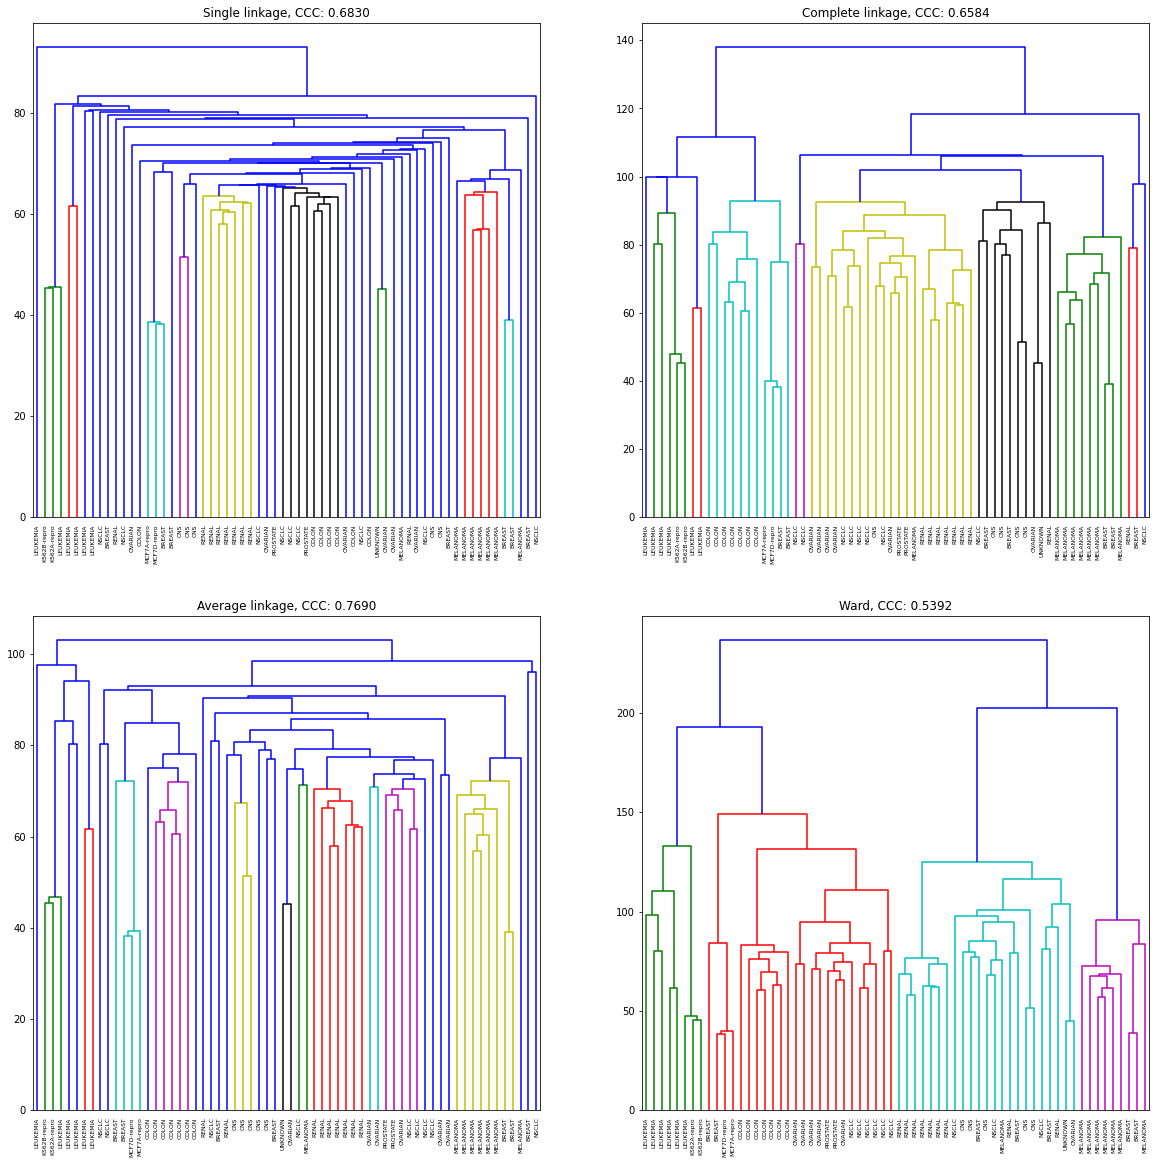

In [14]:
# Condensed distance matrix:
D = pdist(X)

fig, ax = plt.subplots(2,2, figsize=(20,20))
ax[0,0].set_title(f'Single linkage, CCC: {cophenet(Z_sl, D)[0]:0.4f}')
dendrogram(Z_sl, ax=ax[0,0], labels=labels);

ax[0,1].set_title(f'Complete linkage, CCC: {cophenet(Z_cl, D)[0]:0.4f}')
dendrogram(Z_cl, ax=ax[0,1], labels=labels);

ax[1,0].set_title(f'Average linkage, CCC: {cophenet(Z_al, D)[0]:0.4f}')
dendrogram(Z_al, ax=ax[1,0], labels=labels);

ax[1,1].set_title(f'Ward, CCC: {cophenet(Z_ward, D)[0]:0.4f}')
dendrogram(Z_ward, ax=ax[1,1], labels=labels);

El enlace medio y completo dio resultados similares, mientras que el enlace único produjo grupos desequilibrados con agrupaciones largas y delgadas. Nos centramos en la agrupación de enlaces promedio, que informa el mayor coeficiente de correlación cofenética.

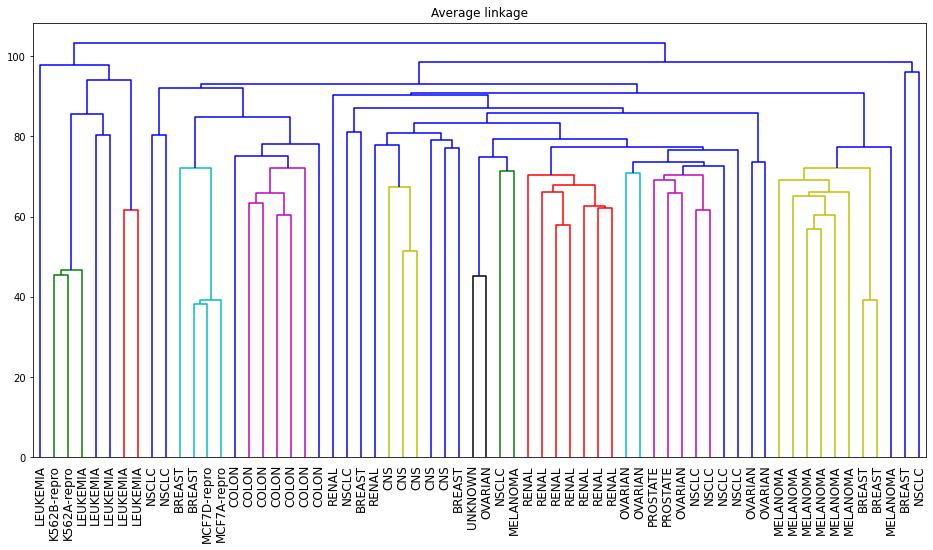

In [16]:
fig = plt.figure(figsize=(16,8))
dendrogram(Z_al, labels=labels, leaf_font_size=12);
plt.title('Average linkage');

Al igual que la agrupación de K-medias, la agrupación jerárquica tiene éxito en la agrupación de cánceres simples. Sin embargo, tiene otras características interesantes. Al cortar el dendrograma a varias alturas, surgen diferentes números de grupos y los conjuntos de grupos se anidan entre sí. En segundo lugar, proporciona información de pedido parcial sobre las muestras.

Podemos cortar el dendrograma a cierta altura para obtener una partición específica. La elección del número de conglomerados k todavía está mal definida. También se pueden utilizar aquí técnicas útiles con K-medias, como el método del codo o la estadística de brecha, pero a menudo se requiere un conocimiento experto para encontrar una partición significativa.

Podemos usar la función `fcluster` para especificar el corte en el árbol de varias formas (mira la documentación).

In [17]:
from scipy.cluster.hierarchy import fcluster

# Specifying the distance at which to cut
labels_1 = fcluster(Z_al, 90, criterion='distance')
print(labels_1)

# Specifying the number of cluster
labels_2 = fcluster(Z_al, 3, criterion='maxclust')
print(labels_2)

[ 6  6  6  6  9  6  6  6  6 10  6  6  6  6  6  6  6  6  6  7  6  6  6  6
  6  6  6  6  6  6  6  6  6  1  1  1  1  1  2  2  3  5  5  5  5  5  5  5
  5  5  5  5  6  4  4  8  8  8  8  8  8  8  8  8]
[2 2 2 2 3 2 2 2 2 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1
 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


Podemos aplicar la agrupación en clústeres tanto a filas como a columnas para una buena visualización.

[]

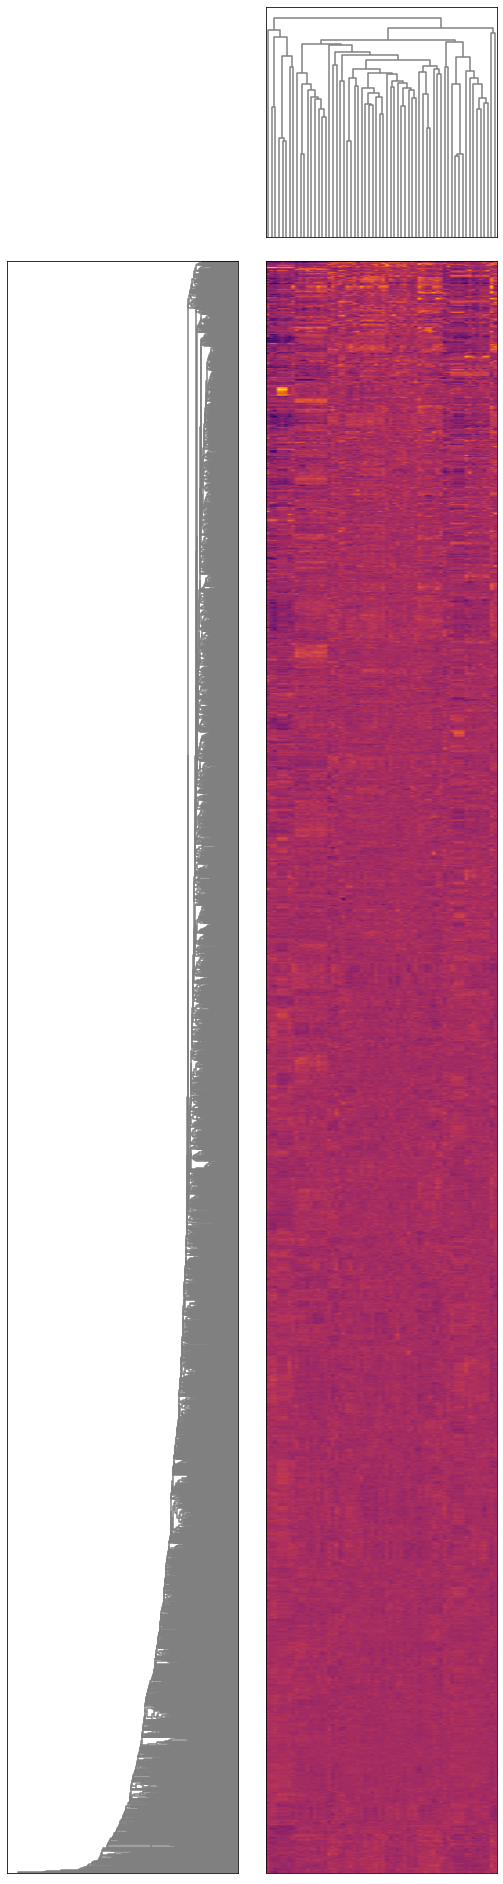

In [18]:
# Perform clustering on rows
Z_rows = linkage(X.T, 'average', optimal_ordering='True')

# Compute and plot first dendrogram.
fig = plt.figure(figsize=(8,32))
# x ywidth height
ax1 = fig.add_axes([0.05,0.1,0.4,0.7])
D1 = dendrogram(Z_rows, orientation='left', distance_sort=True, color_threshold=0, link_color_func=lambda k: 'grey')
ax1.set_yticks([])
ax1.set_xticks([])

#Compute and plot second dendrogram.
ax2 = fig.add_axes([0.5,0.81,0.4,0.1])
D2 = dendrogram(Z_al, orientation='top', distance_sort=True, color_threshold=0, link_color_func=lambda k: 'grey')
ax2.set_yticks([])
ax2.set_xticks([])

#Compute and plot the heatmap
ax3 = fig.add_axes([0.5,0.1,0.4,0.7])
im = ax3.imshow(X[D2['leaves']].T[D1['leaves']], cmap='inferno', aspect='auto')
ax3.set_yticks([])
ax3.set_xticks([])

**Nota**: Existe una implementación muy superior en términos de uso de memoria llamada `fastcluster` útil para grandes conjuntos de datos. Obtenga más información sobre el módulo fastcluster http://danifold.net/fastcluster.html. SciKit-Learn también proporciona una implementación compatible con su API para su uso en pipelines complejos de ML.